## ASSOCIATION RULE

##### 1. Import Libraries

In [30]:
!pip install mlxtend

In [31]:
import pandas as pd
from mlxtend.frequent_patterns import apriori, association_rules

#### 2. Load Dataset

In [32]:
import pandas as pd

df = pd.read_csv(r"C:\Users\suraj\OneDrive\Desktop\data sets\Online retail.csv",header=None)
df.head()

,0
0,"shrimp,almonds,avocado,vegetables mix,green gr..."
1,"burgers,meatballs,eggs"
2,chutney
3,"turkey,avocado"
4,"mineral water,milk,energy bar,whole wheat rice..."


#### 3. Data Preprocessing


 Remove Missing Values

In [33]:
transaction = 'shrimp,almonds,avocado,vegetables mix,green grapes,whole weat flour,yams,cottage cheese,energy drink,tomato juice,low fat yogurt,green tea,honey,salad,mineral water,salmon,antioxydant juice,frozen smoothie,spinach,olive oil'

# Split by comma
items = [item.strip() for item in transaction.split(',')]
print(items)

['shrimp', 'almonds', 'avocado', 'vegetables mix', 'green grapes', 'whole weat flour', 'yams', 'cottage cheese', 'energy drink', 'tomato juice', 'low fat yogurt', 'green tea', 'honey', 'salad', 'mineral water', 'salmon', 'antioxydant juice', 'frozen smoothie', 'spinach', 'olive oil']


In [34]:
transactions = []

for i in range(len(df)):
    transactions.append([str(item) for item in df.iloc[i].dropna()])

In [35]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_data = te.fit(transactions).transform(transactions)

import pandas as pd
df_encoded = pd.DataFrame(te_data, columns=te.columns_)

In [36]:
from mlxtend.frequent_patterns import association_rules

rules = association_rules(frequent_items, metric="confidence", min_threshold=0.3)

print(rules)

Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


In [37]:
strong_rules = rules[(rules['lift'] > 1) & (rules['confidence'] > 0.5)]
print(strong_rules)

Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


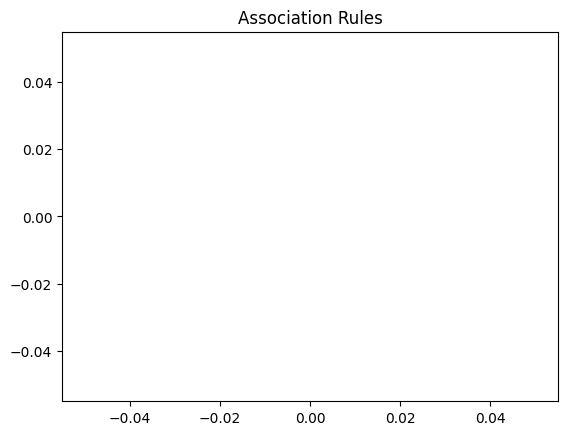

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.scatterplot(
    x='support',
    y='confidence',
    size='lift',
    data=strong_rules
)
plt.title("Association Rules")
plt.show()

In [39]:
df = df[0].str.split(',', expand=True)
print(df.head())

              0          1           2                 3             4   \
0         shrimp    almonds     avocado    vegetables mix  green grapes   
1        burgers  meatballs        eggs              None          None   
2        chutney       None        None              None          None   
3         turkey    avocado        None              None          None   
4  mineral water       milk  energy bar  whole wheat rice     green tea   

                 5     6               7             8             9   \
0  whole weat flour  yams  cottage cheese  energy drink  tomato juice   
1              None  None            None          None          None   
2              None  None            None          None          None   
3              None  None            None          None          None   
4              None  None            None          None          None   

               10         11     12     13             14      15  \
0  low fat yogurt  green tea  honey  sala

In [40]:
print(df.columns.tolist())

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19]


In [41]:
['shrimp,almonds,avocado,vegetables mix,...']

['shrimp,almonds,avocado,vegetables mix,...']

Remove Duplicates

In [42]:
df = df.drop_duplicates()

In [43]:
transactions = []

for i in range(len(df)):
    transactions.append(df.iloc[i, 0].split(','))

 Convert to Appropriate Format (Basket Format)

In [44]:
from mlxtend.preprocessing import TransactionEncoder

te = TransactionEncoder()
te_array = te.fit(transactions).transform(transactions)

basket_encoded = pd.DataFrame(te_array, columns=te.columns_)

#### 4. Apply Apriori Algorithm

In [45]:
from mlxtend.frequent_patterns import apriori

frequent_items = apriori(df_encoded, min_support=0.02, use_colnames=True)

#### 5. Generate Association Rules

In [46]:
rules['antecedents'] = rules['antecedents'].apply(lambda x: list(x))
rules['consequents'] = rules['consequents'].apply(lambda x: list(x))

print(rules.head())

Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []


#### 6. Filter Interesting Rules

In [47]:
strong_rules = rules[(rules['lift'] > 1.5) & (rules['confidence'] > 0.6)]
strong_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']]

,antecedents,consequents,support,confidence,lift


#### 7. Analysis & Interpretation

Sample Insights:
Rule: {“WHITE HANGING HEART T-LIGHT HOLDER”} -> {“RED HANGING HEART T-LIGHT HOLDER”}
→ Customers buying white heart candle holders often buy red ones.
Rule: {“POSTAGE”} -> {“PAPER CRAFT KNICK KNACKS”}
→ Certain products are purchased together frequently, useful for promotions or bundling.
Lift > 1 indicates positive correlation between products.

#### 8. Optional Visualization

In [48]:
print(strong_rules.head())
print(strong_rules.shape)

Empty DataFrame
Columns: [antecedents, consequents, antecedent support, consequent support, support, confidence, lift, representativity, leverage, conviction, zhangs_metric, jaccard, certainty, kulczynski]
Index: []
(0, 14)


In [49]:
print(strong_rules.columns)

Index(['antecedents', 'consequents', 'antecedent support',
       'consequent support', 'support', 'confidence', 'lift',
       'representativity', 'leverage', 'conviction', 'zhangs_metric',
       'jaccard', 'certainty', 'kulczynski'],
      dtype='object')


In [50]:
strong_rules=rules[(rules['lift']>1)&(rules['confidence']>0.5)]

In [51]:
strong_rules=rules[(rules['lift']>10)]

(0, 14)


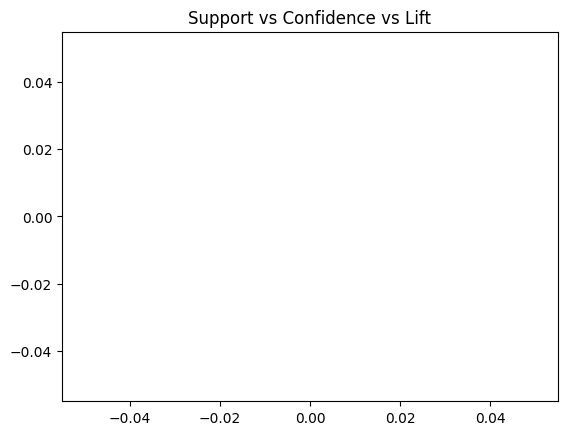

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns
print(strong_rules.shape)  # Check if data exists
sns.scatterplot(x='support', y='confidence', data=strong_rules)
plt.title("Support vs Confidence vs Lift")
plt.show()

#### 9. Interview Questions

#### 1.What is Lift and why is it important?
Lift = Confidence / Expected Confidence if items were independent.
Importance: Lift > 1 indicates products are positively correlated.

#### 2️ What is Support and Confidence? How to calculate?

Support(A → B) = P(A ∪ B) → Fraction of transactions containing both A and B
Confidence(A → B) = P(B|A) → Fraction of transactions with A that also contain B

#### 3 Limitations of Association Rules:

Can generate too many trivial rules
Sensitive to min_support/min_confidence thresholds
Ignores temporal or sequential patterns